Here I will try to learn how to deploy a model in the cloud and make it usable from another machine without having to train the model again.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn import linear_model

import pickle

First, we take the model from the previous section and train this again.

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].fillna('NA')
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

In [ ]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# One-hot encoding
dicts = df.drop(['converted'], axis=1).to_dict(orient='records')
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

test_dict = df_test.to_dict(orient='records')
X_test = dv.transform(test_dict)

model = linear_model.LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, df_train.converted)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

Now, we export the model to a binary file. We have to use both the model constructor and the dictionary vectorizer (otherwise the one-hot-encoding won't be possible when loading the model).

In [4]:
outfile = 'model_LogReg_CourseLeadScoring.bin'
	
with open(outfile, 'wb') as f_out:
    pickle.dump((dv, model), f_out)

Now, load the model from the binary file.

In [2]:
model_file = 'model_LogReg_CourseLeadScoring.bin'
with open(model_file, 'rb') as f_in:
    dv, model = pickle.load(f_in)

In [ ]:
customer = df.iloc[0].to_dict()
X = dv.transform([customer])
model.predict_proba(X)[0,1]

In [6]:
customer

{'lead_source': 'paid_ads',
 'industry': 'NA',
 'number_of_courses_viewed': 1,
 'annual_income': 79450.0,
 'employment_status': 'unemployed',
 'location': 'south_america',
 'interaction_count': 4,
 'lead_score': 0.94,
 'converted': 1}

In [7]:
X = dv.transform([customer])

In [8]:
model.predict_proba(X)[0,1]

np.float64(0.5757700893869201)

Let's start with some basic creation of web services. For this part, we will need to use scripts rather than notebooks. In the file "customer.py" we define the web application itself, while in "deploy_on_web_customer.py" we apply this to a specific customer instance of input values and print some results. To deploy the model as a web service, we use a Web Server Gateway Interface (WSGI) called waitress. In a terminal, we run

waitress-serve --host=127.0.0.1 --port=9696 customer:app

and then, in another terminal, run "deploy_on_web_customer.py" as a standard python script.

Now, let's learn some things about virtual environments. There are several of them, and each one is aimed at a different purpose:
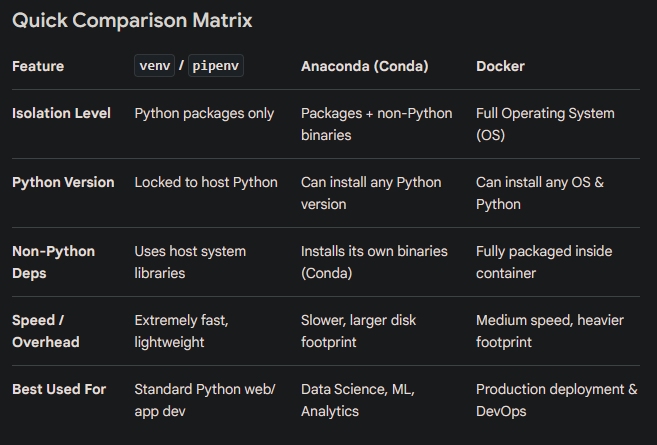